# BBT 3201: Artificial Intelligence
## Practical Exercise 5: Data Cleaning

**Group Members (ASSIGNMENT FIVE):**
* 138547 DEE EMMANUEL
* 169282 MATHEWS ZIMBA
* 168653 STEPHEN WANJOGU NGATARA
* 169085 ABRAHAM KUOL AJUONG
* 112409 IAN KAHARE GICHERO

**1. Upload the Airplane Crashes Dataset.**
Import the necessary data manipulation and visualization libraries, and load the CSV dataset into a pandas DataFrame.*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


**2. Determine the number of rows and columns in the dataset.**
*Use the `.shape` attribute to extract and print the exact dimensions of the dataframe.*

In [ ]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 5268
Number of columns: 13


**3. Display the last 75 rows in the dataset.**
*Use the `.tail()` function to view the bottom 75 records.*

In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


**4. Each column except the first one has some missing data. For each column, name the most appropriate method for treating the missing data.**

*   **Time, Flight #, Route, Registration, cn/In,  (Categorical/Text Data):**
    *   **Method:** Impute with a placeholder string like "Unknown" or "Unrecorded".
    *   **Justification:** These are specific identifiers or unique text summaries. Mathematical imputation is impossible, and filling with the "mode" could fabricate false information about a crash.
*   **Location, Operator, Type (Categorical Data):**
    *   **Method:** Placeholder imputation ("Unknown").
    *   **Justification:** Replacing missing values with "Unknown" is the safest approach to prevent wrongly attributing a crash to an innocent airline, aircraft type, or location.
*   **Aboard, Fatalities, Ground (Numerical Data):**
    *   **Method:** Median imputation.
    *   **Justification:** The dataset contains massive outliers (e.g., crashes with 0 fatalities vs. crashes with 500+ fatalities). Because extreme values severely skew the `mean`, the `median` provides a much more accurate and safe measure of central tendency for missing numerical casualty counts.

**5. Create a new dataframe from the raw/uncleaned data called ‘fatality_locations’ with the following columns: ‘Date’, ‘Location’, ‘Aboard’, ‘Fatalities’.**
*Extract a subset of the original dataframe into a new variable.*

In [ ]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


**6. Determine the date of the highest number of recorded fatalities from this new dataframe.**
*Identify the index of the maximum value in the 'Fatalities' column and use it to locate the corresponding 'Date'.*

In [ ]:
highest_fatalities_idx = fatality_locations['Fatalities'].idxmax()
date_highest_fatalities = fatality_locations.loc[highest_fatalities_idx, 'Date']
print(f"Date of highest fatalities: {date_highest_fatalities}")

Date of highest fatalities: 03/27/1977


**7. Compare the number of passengers aboard to the number of fatalities per crash. Are there any recorded crashes where there were no fatalities? If so, how many?**
*Filter the dataframe to isolate rows where the 'Fatalities' value is exactly 0, then calculate the length of that subset.*

In [ ]:
# Find crashes with zero fatalities
zero_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
zero_fatalities_count = len(zero_fatalities)

print(f"Are there crashes with no fatalities? {'Yes' if zero_fatalities_count > 0 else 'No'}")
print(f"Number of recorded crashes with zero fatalities: {zero_fatalities_count}")

Are there crashes with no fatalities? Yes
Number of recorded crashes with zero fatalities: 58


**8. In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries.**
*Use `.str.rsplit()` to separate the string at the last comma, splitting the data into 'Region' and 'U.S. State/Country' columns.*

In [ ]:
# Split the 'Location' column on the last comma
split_locations = fatality_locations['Location'].str.rsplit(', ', n=1, expand=True)

# Assign the first part (index 0) to 'Region' and the second part (index 1) to 'U.S. State/Country'
fatality_locations['Region'] = split_locations[0]
fatality_locations['U.S. State/Country'] = split_locations[1]

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,U.S. State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


**9. Order the dataframe by the number of fatalities from highest to lowest and select the first 100.**
*Sort the dataframe using `.sort_values()` in descending order and use `.head(100)` to retrieve the top 100 records.*

In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,U.S. State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


**10. Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State.**
*Aggregate the top 25 crashes by summing the fatalities grouped by 'U.S. State/Country', then plot the distribution using matplotlib and seaborn palettes.*

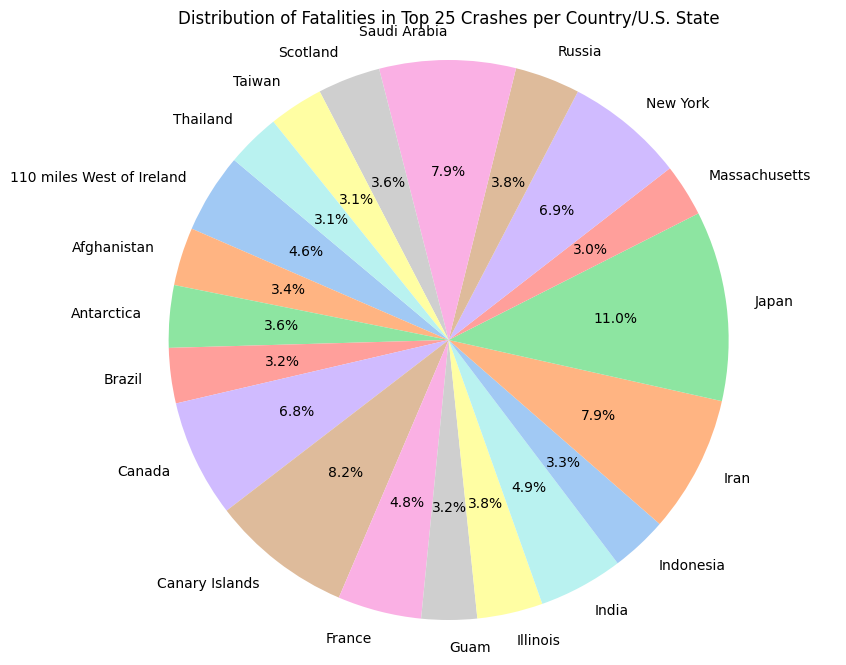

In [ ]:
# Get the top 25 crashes by fatalities
top_25_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(25)

# Group by the 'U.S. State/Country' column and sum the fatalities
state_country_distribution = top_25_fatalities.groupby('U.S. State/Country')['Fatalities'].sum()

# Generate the pie chart
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(state_country_distribution)]

plt.pie(state_country_distribution, labels=state_country_distribution.index,
        autopct='%1.1f%%', colors=colors, startangle=140)

plt.title('Distribution of Fatalities in Top 25 Crashes per Country/U.S. State')
plt.axis('equal')
plt.show()